In [ ]:
from sts.mktdata.ticker import Ticker
from datetime import date, datetime, timedelta
import pandas
import numpy
from sts.utils import get_logger
from pathlib import Path
from sts.apps.research.spy_internal_stats import spy_internal_stats_data, get_log_diff, get_spy_internal_stats_report
from sts.plots import plot_multi_time_series
from sts.quant.trend.trend import get_trend_score
from sts.signals.target import get_predicted_value
pandas.options.plotting.backend = 'plotly'
ticker = Ticker('us/etf.yml')

In [ ]:
df = spy_internal_stats_data(date(2020, 6, 1), date(2026, 2, 16))

In [8]:
spy_df = ticker.history('SPY', '2020-06-01', '2026-02-16')
spy_df = spy_df.set_index('ts')
spy_df['y'] = get_predicted_value(spy_df, 'close', lookahead=5, vol_win = 40)

In [79]:
for n in [5, 10, 20]:
    spy_df[f'y_{n}'] = get_predicted_value(spy_df, 'close', lookahead=n, vol_win = n * 4)

In [26]:
#df.to_parquet('~/data/tmp/spy_internal_stats.parquet')
#df = pandas.read_parquet('~/data/tmp/spy_internal_stats.parquet')
#spy_df.to_parquet('~/data/tmp/spy_df.parquet')
#spy_df = pandas.read_parquet('~/data/tmp/spy_df.parquet')
spy_df['y'] = spy_df['y'].clip(-2, 2)

In [10]:
cols = ['SPY', 'SOXX/SPY', 'cyclical/defensive', 'discretionary/staples',
       'high_beta/low_beta', 'LQD/IEF', 'VIX3M/VIX']

In [ ]:
data

In [27]:
data = spy_df[['y']].copy()
for col in cols:
    data[f'{col}_trend'] = get_trend_score(df[col], 10)

In [ ]:
for col in cols[1:]:
    fig = plot_multi_time_series([df['SPY_trend'], df[f'{col}_trend']], yn_list=['y1', 'y2'], ypos_left = [True, False], title=f'{col} vs SPY trend score')
    fig.show()

In [ ]:
spy_df.dropna()  

In [44]:
data2 = data.copy()
bins = [-2, -1, 0, 1, 2]
labels = [-1.5, -0.5, 0.5, 1.5]
for col in data2.columns:
    if col == 'y':
        continue
    data2[col] = pandas.cut(data2[col].clip(bins[0], bins[-1]), bins=bins, labels=labels)

In [71]:
data3 = data.drop('y', axis = 1).astype('float')

In [76]:
t = data3.mean(axis = 1)

In [82]:
spy_df['t'] = t

In [87]:
spy_df.iloc[:, -5:].corr()

,y,y_5,y_10,y_20,t
y,1.000000,0.994458,0.665792,0.447470,-0.033524
y_5,0.994458,1.000000,0.658098,0.443689,-0.011815
y_10,0.665792,0.658098,1.000000,0.655801,-0.024722
y_20,0.447470,0.443689,0.655801,1.000000,0.017149
t,-0.033524,-0.011815,-0.024722,0.017149,1.000000


In [88]:
plot_multi_time_series([spy_df['y_20'], t], yn_list=['y1', 'y2'], ypos_left = [True, False], title=f't vs y')

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

def find_significant_regimes(
    df,
    cat_cols,
    target='y',
    popmean=0,
    alpha=0.05,
    alternative='greater',
    min_group_size=5,
    max_comb_size=None
):
    """
    Find regimes (combinations of categorical columns) where the mean of target
    is significantly greater than (or different from) a threshold.

    Parameters
    ----------
    df : pandas.DataFrame
        Input data.
    cat_cols : list of str
        Names of the 5 categorical columns.
    target : str, default='y'
        Name of the continuous target column.
    thresh : float, default=0
        Threshold value for the one‑sample t‑test.
    alpha : float, default=0.05
        Significance level.
    alternative : {'greater', 'less', 'two-sided'}, default='greater'
        Direction of the test.
    min_group_size : int, default=5
        Minimum number of observations required to test a regime.
    max_comb_size : int or None, default=None
        Maximum number of columns to combine (e.g., 3 to test only up to 3‑way interactions).
        If None, all combinations up to len(cat_cols) are considered.

    Returns
    -------
    pandas.DataFrame
        Table with columns:
        - regime : string description of the filter
        - columns : list of columns used
        - filter : dict mapping column to value(s)
        - size : number of observations
        - mean : mean of target in this regime
        - std : standard deviation
        - t_stat : t‑statistic
        - p_value : p‑value
        - significant : bool (always True here, kept for compatibility)
    """
    results = []
    n_cols = len(cat_cols)
    if max_comb_size is None:
        max_comb_size = n_cols

    # Loop over all non‑empty subsets of columns
    for k in range(1, max_comb_size + 1):
        for cols in combinations(cat_cols, k):
            # Group by the chosen columns
            grouped = df.groupby(list(cols))[target]

            for values, group in grouped:
                if len(group) < min_group_size:
                    continue

                mean = group.mean()
                std = group.std(ddof=1)

                # One‑sample t‑test against thresh
                if alternative == 'greater':
                    t_stat, p_value = stats.ttest_1samp(group, popmean, alternative='greater')
                elif alternative == 'less':
                    t_stat, p_value = stats.ttest_1samp(group, popmean, alternative='less')
                else:  # two‑sided
                    t_stat, p_value = stats.ttest_1samp(group, popmean)

                if p_value < alpha:
                    # Build a readable description of the regime
                    if isinstance(values, tuple):
                        filter_dict = dict(zip(cols, values))
                        regime_desc = " & ".join([f"{col}={val}" for col, val in zip(cols, values)])
                    else:
                        filter_dict = {cols[0]: values}
                        regime_desc = f"{cols[0]}={values}"

                    results.append({
                        'regime': regime_desc,
                        'columns': list(cols),
                        'filter': filter_dict,
                        'size': len(group),
                        'mean': mean,
                        'std': std,
                        't_stat': t_stat,
                        'p_value': p_value,
                        'significant': True
                    })

    if results:
        return pd.DataFrame(results)
    else:
        return pd.DataFrame()  # empty result

In [ ]:
res = find_significant_regimes(data2.dropna(), cat_cols=[col for col in data2.columns if col != 'y'], popmean=0, alpha=0.1, alternative='less', min_group_size=5, max_comb_size=3)

In [ ]:
t = res[res['filter'].apply(lambda x: ('SPY_trend' in x) and  (x['SPY_trend'] == '0.5') )]

In [45]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
cat_cols = [col for col in data2.columns if col != 'y']

In [49]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
tree = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
data3 = data2.dropna()
tree.fit(data3[cat_cols].values, data3['y'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

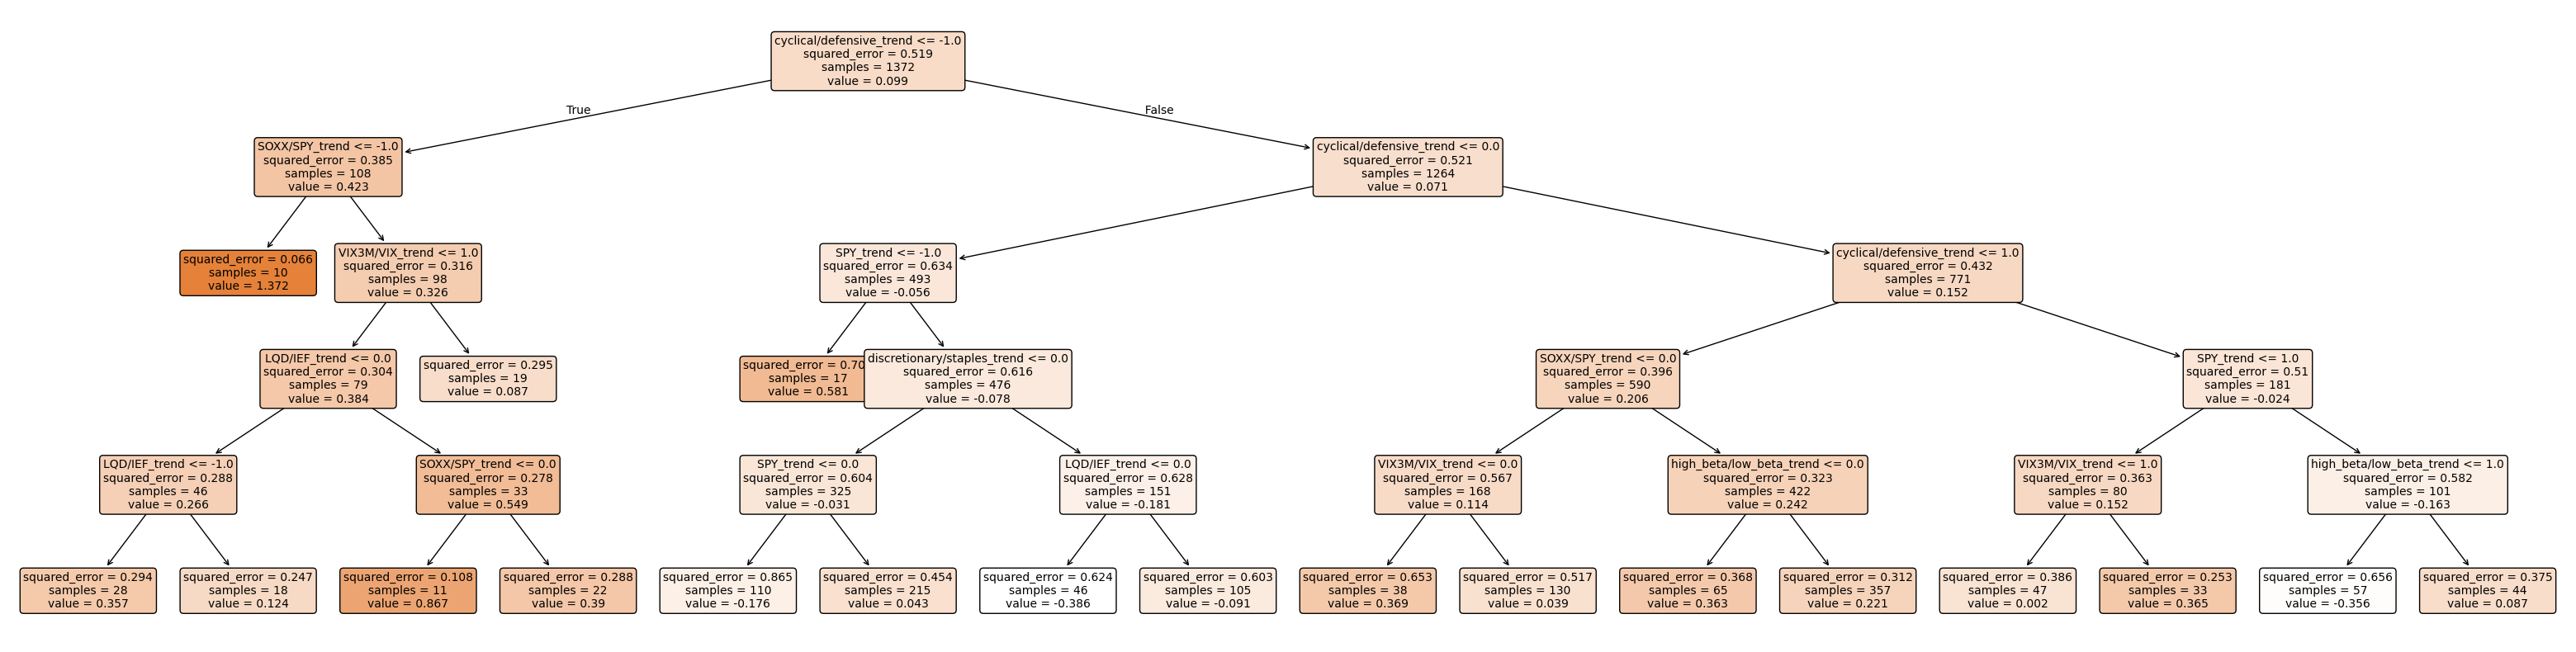

In [50]:
plt.figure(figsize=(40, 10))
plot_tree(tree, feature_names=cat_cols, filled=True, rounded=True, fontsize=10)
plt.show()

In [48]:
data2

,y,SPY_trend,SOXX/SPY_trend,cyclical/defensive_trend,discretionary/staples_trend,high_beta/low_beta_trend,LQD/IEF_trend,VIX3M/VIX_trend
ts,,,,,,,,
2020-06-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-02 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-03 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-04 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-05 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-02-09 00:00:00-05:00,NaN,0.5,1.5,-0.5,-1.5,-0.5,0.5,0.5
2026-02-10 00:00:00-05:00,NaN,0.5,1.5,-0.5,-1.5,-0.5,0.5,0.5
2026-02-11 00:00:00-05:00,NaN,0.5,1.5,-0.5,-1.5,-0.5,0.5,0.5
